huggingface核心组件使用。

datasets数据工程（ollama/vLLM/LMDeploye模型部署推理）

DeepSpeed分布式训练/Llama Factory/Xtuner

**SFT微调训练/LoRA/QLoRA**

模型合并，打包，部署\HF转GGUF

**模型量化核心算法与最佳实践**

模型蒸馏原理及动手实践一个蒸馏模型

**模型评估方法（loss，用户满意度）和最佳实践/OpenCompass**

跨模态大模型应用

流程控制和有行业风格一定要微调。

RAG：适合文本资料变动多的情况，成本低。

微调：有专业风格的客服形象，成本高一点。减少幻觉。

1.模型微调：使用行业数据训练——增加模型内化能力

价值：专业化，精准化，任务适配。

2. 微调流程：

目标设定——数据准备——模型选择——微调训练——验证测试（上线优化）

数据要准备哪些？模型要选择哪个？参数调哪些，怎么调？

微调的目标设定：分类任务，生成任务，序列标注

**分类任务：**

是什么：给定输入，判定其属于哪个（或哪些）类别。

输入/输出：输入=一段文本/图像等；输出=离散标签（单标签或多标签）。

损失函数：单标签多类：交叉熵（softmax CE）。多标签：独立二分类的二元交叉熵（sigmoid + BCE）

评估：Accuracy、Precision/Recall/F1（macro/micro）、ROC-AUC（多标签/二分类）。

典型场景：情感分类（正/负/中），垃圾短信识别，意图识别，新闻话题分类。

**生成任务（Text Generation）：**

是什么：根据输入生成连续文本或结构化文本。

输入/输出：输入=指令/上下文；输出=自由文本或受约束的结构化文本（JSON、SQL等）。

损失函数：自回归交叉熵（next-token CE）。

评估：ROUGE/BLEU/METEOR、BERTScore、BLEURT、Exact Match（QA）、人评（流畅性/事实性）。

典型场景：摘要生成、问答、对话、改写、机器翻译、SQL/代码生成。

**序列标注（Sequence Labeling）：**

是什么：对序列中的每个元素（通常是token/字词）打标签。

输入/输出：输入=标记化后的序列；输出=与序列等长的标签序列（如BIO/BILOU）。

损失函数：token级交叉熵；有时叠加CRF层用CRF对数似然。

评估：Token级Precision/Recall/F1；实体级（更常用）：严格匹配的F1（开始-结束和类型都要对）。

典型场景：实体识别（人名/地名/机构/药物/症状）、意图识别、关键词/方面词抽取、词性标注、槽位填充。

如何判断是使用大模型还是传统方法。

传统方法：贝叶斯，SVM，缺点需要大量人工特征，但是优点是在资源效率方面表现好。

大模型自动识别语意

大模型+传统特征

知识蒸馏

领域适配

要根据任务，数据规模，计算成本来判断用什么方法。

情感分析

深度学习只能处理数值。

transformers里面会有一个训练器，这个训练器会自动地根据类别去映射数字。

**数据要求：多样性，平衡性**

正面和负面的**例子数**是基本差不多的，数据的**内容要多样**，才能提高模型泛化能力。

处理数据：

补充 含有少量缺失的数据。

去掉 大量缺失的数据。

不然模型的能力会受到影响。

如果训练后的模型和基座模型的效果差不多，则要想一下是不是训练数据太烂的原因。

**获取标签**的方法，需要根据业务场景选择合适的打标签方式：

1. 人工标注，准确率最高（千条之内）。

2. 大模型自动标注：GPT读取文本，提示打标注，然后人工抽样检查一下，速度快，成本低，大模型自己本身可能有偏差。

3. 自监督：利用现有结构，比如电商评论星级。

4. 弱监督学习：使用多个弱分类器，投票决定标签，适合快速构建大致可用的数据集。比如情感词典，简单的机器学习的模型。

5. 规则，关键词标签：用情感词典判断，比如“好看”，“感动”标注1，“差劲”，“拖沓”标注0.但会导致误判，因为识别不出讽刺含义（用好词骂人）。

数据准备阶段的问题：

1.数据杂乱——需要数据清洗。重复内容，特殊字符，短文本，大小写不统一，html标签。

# **模型选择**

规模：

规模大的话占用缓存，推理速度慢。

规模小的如mini Distil不占用缓存，轻量级适合部署。

现在选择一个基于BERT的模型hfl/chinese-roberta-wwm-ext，这个模型理解中文任务，但是不会做情感分类（方便我们微调）。

In [1]:
import os
os.environ["WANDB_DISABLED"] = "true"
#防止使用trainer的时候让我输入API_key

In [2]:
!pip -q install -U transformers
!pip -q install -U datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 112.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 94.0 MB/s eta 0:00:00


In [3]:
#将模型下载到本地
from transformers import AutoModelForSequenceClassification, AutoTokenizer, TrainingArguments, Trainer
import os
from google.colab import drive

In [4]:
# 要下载的模型
model_name = "hfl/chinese-roberta-wwm-ext"

# 指定保存路径（Colab 本地）
cache_dir = "/content/models/chinese-roberta-wwm-ext"
os.makedirs(cache_dir, exist_ok=True)

# 下载并加载（会把权重缓存到 cache_dir）
model = AutoModelForSequenceClassification.from_pretrained(model_name, cache_dir=cache_dir)
tokenizer = AutoTokenizer.from_pretrained(model_name, cache_dir=cache_dir)

print("loaded yes. files saved in:", cache_dir)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/412M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at hfl/chinese-roberta-wwm-ext and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/19.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

loaded yes. files saved in: /content/models/chinese-roberta-wwm-ext


In [5]:
import pandas as pd
df = pd.read_csv("chinese sentiment.csv", encoding="gb18030")   # 读旧文件
df.to_csv("chinese sentiment_utf8.csv", index=False, encoding="utf-8")  # 转成UTF-8

In [6]:
from datasets import load_dataset#用于加载和处理数据集

dataset = load_dataset("csv",data_files="chinese sentiment_utf8.csv")
#加载csv数据集
#返回的是 DatasetDict（像字典），通常只有一个键："train"。

model_name="hfl/chinese-roberta-wwm-ext"
tokenizer=AutoTokenizer.from_pretrained(model_name)
#导入分词器，分词器将文本转换为模型可接受的输入格式（如input_ids, attention_mask等）

Generating train split: 0 examples [00:00, ? examples/s]

tokenizer_config.json:   0%|          | 0.00/19.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

**transformers 是什么？**

transformers是一个python的库，专门做文本分类，文本问答等文本信息的神经网络架构。

BERT和transformers的底层核心都是transformers。

transformers的核心是注意力机制。

传统RNN是一字一字顺序读的，transformers是一句话读完就知道主谓关系，一眼就能看到整句话。

一个统一的 NLP/多模态模型库，封装了上千个预训练/指令微调模型（BERT、RoBERTa、LLaMA、Qwen、T5、Whisper、CLIP…），并提供统一 API 来：

加载模型与分词器（Tokenizer）

完成推理（inference）与微调（fine-tuning）

AutoTokenizer：把文本 ↔ token id

AutoModel / AutoModelFor*：模型骨架 / 带任务头（如分类、序列标注、Seq2Seq等）

Config：模型结构与超参（层数、隐藏维度、dropout 等）

经验法则：优先用 Auto 类（会根据 checkpoint 自动选择正确架构）。

**该用哪个接口？**

只想跑通任务：pipeline

需要批量/自定义后处理：Auto 接口 + 手写推理

要训练/微调：Trainer 或 accelerate + peft（LoRA）

# **Tokenizer分词器**：

将文本变成一串数字的工具。

user：我今天很开心。

LLM:[101,2769,791,1921,2523,2458,2552,102,0,0]

模型负责理解顺序关系，tokenizer负责拆，把人类语言变成模型能看懂的数字，相当于一个翻译官。

把数字变成向量这件事是不用手动的，它自动可以完成的。我们只需要通过tokenizer把每个字拆成对应的数字。huggingface高层的API会直接去把这些数字变成向量。

如果没有用到tokenizer，那么我自己要去做向量化，要去做分词，要去做映射。

在微调的阶段，整个模型的训练就是在调整如何把向量映射到正确的标记中。

分词器示例：

In [7]:
#加载中文RoBERTa分词器
tokenizer = AutoTokenizer.from_pretrained("hfl/chinese-roberta-wwm-ext")

#示例句子
text="我今天很高兴"

#使用分词处理器
tokens = tokenizer.tokenize(text)
encoding = tokenizer(text, truncation=True, padding="max_length", max_length=10)
#若文本太长，截断到指定的最大长度。填充到固定长度（这里是 128）。短于 128 的，在序列末尾补 [PAD]。
#可选值："longest"：按本批数据里最长样本对齐（常与 DataCollatorWithPadding 动态填充一起用）。
#目标序列的总长度上限（包含特殊符号，如 [CLS]、[SEP]、[PAD]）。超过就截断；不足就填充。单位是 token 数

In [8]:
print("原始文本：", text)
print("tokens：", tokens)
print("encoding：", encoding)

原始文本： 我今天很高兴
tokens： ['我', '今', '天', '很', '高', '兴']
encoding： {'input_ids': [101, 2769, 791, 1921, 2523, 7770, 1069, 102, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 0, 0]}


为什么6个字对应10个数字？多了4个出来？

第一个数字101[CLS]代表整个句子的开始，做分类的时候用的，因为我们要给模型整个句子去理解它的情感，模型是通过每个字的向量感受的，所以说用101作为一个开始的符号。

tokens的对应数字结束后的第一个数字是102[SEP].102有两个作用，一个是作为两个句子间的分隔（分隔不同的句子），第二个作用是标记句子结束了。

最后的两个0[PAD],是因为我们设置的最大长度10，因为模型的输入必须是同一长度的，如果我们设置了最大长度10，如果不够10，则我们会用0来补充代替。

如果长度设置小于输入的text长度，则text会被截断，最后一个符号是102[SEP].

In [9]:
#数据预处理，把text转为模型输入格式。
def preprocess(example):
  #example是dataset中的一条数据记录（字典形式），截断超过max_length的文本内容
  return tokenizer(example["text"],truncation=True,padding="max_length",max_length=128)
  #padding填充到固定长度max_length，最大长度为128


In [10]:
"""
#批处理，和上面的代码同样的作用
def preprocess_batch(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=128)

encoding_dataset = dataset["train"].map(
    preprocess_batch,
    batched=True,                # 一次传入一个“批次”
    batch_size=1000,             # 可选
    remove_columns=dataset["train"].column_names,  # 处理后丢掉原列，比如 text/label
    desc="Tokenizing"
)
"""

'\n#批处理，和上面的代码同样的作用\ndef preprocess_batch(batch):\n    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=128)\n\nencoding_dataset = dataset["train"].map(\n    preprocess_batch,\n    batched=True,                # 一次传入一个“批次”\n    batch_size=1000,             # 可选\n    remove_columns=dataset["train"].column_names,  # 处理后丢掉原列，比如 text/label\n    desc="Tokenizing"\n)\n'

目的：把原始文本列（"text"）转换成模型能吃的“张量字典”（如 input_ids、attention_mask 等）。

步骤：根据 model_name（如 "hfl/chinese-roberta-wwm-ext"）自动加载匹配的分词器配置和词表（含特殊符号如 [CLS]、[SEP]、[PAD] 等）。

返回的 tokenizer 负责把字符串变成“token 序列”和对应的张量。

In [11]:
print(dataset.keys())

dict_keys(['train'])


在 Datasets 里，split 就是数据集的一个命名分区（逻辑切片），表单，常见有：

train：用于训练

validation/dev：用于调参与早停

test：用于最终评估
名字不强制，实质就是 DatasetDict 里的键。

In [12]:
print(dataset["train"][0])

{'text': '商务大床房，房间很大，床有2M宽，整体感觉经济实惠不错!', 'label': 1}


dataset["train"] 是什么？

它是一个 Dataset（单表/单 split 对象），内部是高效的 Arrow 表。

In [13]:
# 统计“问题样本”（None 或 空白）
bad = dataset["train"].filter(
    lambda x: (x.get("text") is None) or (isinstance(x.get("text"), str) and x["text"].strip() == "")
)
print(len(bad))           # 有多少条问题样本
if len(bad) > 0:
    print(bad[0])

Filter:   0%|          | 0/599 [00:00<?, ? examples/s]

0


In [14]:
#对训练集中的每一条数据应用数据预处理函数，返回编码后的数据集，dataset["train"]是CSV文件中默认的split
encoding_dataset=dataset["train"].map(preprocess)

Map:   0%|          | 0/599 [00:00<?, ? examples/s]

.map() 是什么、怎么用？

.map() 会把你提供的函数应用到数据集上（逐样本或逐批次），返回一个新的 Dataset

DatasetDict（dataset）≈ 一个 Excel 工作簿（.xlsx 文件）
里面有多个“表”。

Dataset（dataset["train"]）≈ 工作簿里的某一张表（sheet）
有列（column_names）和行（样本）。

列：dataset["train"].column_names 就像 Excel 的列名。

行：dataset["train"][0] 返回第 1 行的数据（字典：{"列名": 值}）。

多行切片：dataset["train"][:5] 返回前 5 行（字典的“列→列表”形式）。

取整列：dataset["train"]["text"] 返回 text 这一整列的列表。

不过要知道它不是真正的 Excel：

内部是 列式存储（Apache Arrow），更快更省内存。

不可原地修改：像 map、filter 都会返回新的 Dataset。

有严格的类型/schema（features），比 Excel 更规范。

**为什么训练完后，保存的分词器tokenizer.json的内容里有很多训练数据里根本没有的生僻字？**

因为是预训练好的分词器（如 hfl/chinese-roberta-wwm-ext 自带的词表），微调不会改它的词表。

把它当成“词典”来理解

预训练模型自带一本文字“词典”（词表），为了覆盖面更广，里面收录了简体、繁体、常见日文汉字、符号，甚至一些预留位（如 [unused1]…）。

你做微调时，只是在更新模型的参数，不会重写这本词典。

所以你保存 tokenizer.json 时，看到的还是那本“大词典”，不要求你的数据里出现过这些字。

**什么时候词表才会“和你的数据强相关”？**

1. 在原词表上加词（常用、推荐）：

适合你的领域里有大量新术语/型号/缩写时：
(新加的词向量会随机初始化，靠后续微调学好。)

In [15]:
"""
new_tokens = ["GSM-R", "R530", "Q/XYZ-2025"]
num_added = tokenizer.add_tokens(new_tokens)
if num_added > 0:
    model.resize_token_embeddings(len(tokenizer))  # 让模型认识新词
"""

'\nnew_tokens = ["GSM-R", "R530", "Q/XYZ-2025"]\nnum_added = tokenizer.add_tokens(new_tokens)\nif num_added > 0:\n    model.resize_token_embeddings(len(tokenizer))  # 让模型认识新词\n'

2. 从头训练一个新分词器（不适合一般微调）
只有“从零训练模型”或“大规模继续预训练”才考虑。否则会和原权重“对不上”，成本很高。

3. 裁剪/精简词表（不建议）
可能会让推理时遇到生词直接崩掉，除非是极小封闭场景 + 蒸馏。

**如何选择方法？**

效果正常就别动：看到生僻字是正常的，不影响使用。

术语被切碎再处理：如果你发现专业词被切成很多小片，按上面“加词”方法补充几个高频术语即可。

**怎么看一个词的切分方式**


In [16]:
"""
text = "超导量子芯片R530"
print(tokenizer.tokenize(text))
print(tokenizer.convert_tokens_to_ids(tokenizer.tokenize(text)))
"""

'\ntext = "超导量子芯片R530"\nprint(tokenizer.tokenize(text))\nprint(tokenizer.convert_tokens_to_ids(tokenizer.tokenize(text)))\n'

# **全量微调训练**

In [17]:
#加载用于文本分类的预训练模型，并设置分类的类别数为2（正面/负面）
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
#做是二分类，所以1. 数据有且只能又2个标签，2. 预训练模型的参数num_label=2

pytorch_model.bin:   0%|          | 0.00/412M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at hfl/chinese-roberta-wwm-ext and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


正常的提示。

意思是：hfl/chinese-roberta-wwm-ext 是通用预训练的基座（做MLM），没有现成的分类头；当你用 AutoModelForSequenceClassification 时，会新建一个随机初始化的 classifier 层，因此日志里说这两组权重是 “newly initialized”。要想拿去做情感分类，就需要微调。

In [18]:
#定义训练参数
#从这几行代码中，我可以决定，我的模型学得有多快，学得有多好

training_args = TrainingArguments(
    output_dir = "output/zh_model",#模型训练完成之后，保存到新的目录中间，下次就不需要重新训练了，直接用现成训练好的模型。
    #以下参数是为了告诉模型怎么去训练，让模型的训练更加可控一点。
    #不管在训练中遇到什么问题，都可以做一个调整。

    per_device_train_batch_size = 8,
    #每次喂给模型的条数。
    #每个设备上的训练batch大小为4，越大的batch对显存的要求越大。
    #常见4，8，16，取决于GPU显存和数据量。如果不知道数据是多还是少，用8就行。
    #小batch是一次只看少量的样本，对显存要求低。但是训练数据比较多的情况下，训练时间会长一些。
    #如果大batch比如32，64，对显存的要求就会高，所以模型微调到后面都要用到GPU。
    #4对显存友好，但是梯度波动比较大，可能需要多次的进行训练的轮次。
    #如果batch设置的比较大，学习起来会稳定一点点，但是显存用得大。
    #每次epoch随机打乱顺序，然后从从打乱后的训练集中抽取4条喂给模型，可以认为它是随机的。

    num_train_epochs = 5,
    #训练轮次为5，即全部数据训练5遍
    #一般微调时设置3-5遍就足够了，这时候模型已经学习到了很多语言知识，只需要去做适配任务就行
    #如果训练太多，死记硬背的话，会导致过拟合，训练少了会导致训练不足。
    #训练5轮是为了让模型有足够的机会能够去学习数据中间的模式，但不至于过度拟合。
    #可以通过验证集的准确性来调整训练的轮次：
    #训练的损失值在某一轮次之后停止下降或者上升了，这就表示过拟合了，这时候就可以停止训练。

    logging_steps = 5,
    #每隔5步打印一次日志
    #可以看loss指标，梯度grad_norm,学习率learning_rate,轮次epoch。
    #日志可以帮助发现训练过程中有什么样的问题。比如说学习率过大，梯度爆炸这样的问题。
    #数据量比较大的情况下，日志太多会影响性能。
    #所以logging_steps要根据数据量来。

    save_steps=20,
    #好处：在训练过程中突然断掉，每10步保存一次模型就能防止出现意外，保证进度不会丢失。不需要重头再来。
    #也要根据数据量选择，数据量大时，save_steps也会占用存储空间。
    #1小时以上的训练任务需要清理旧节点。


    #如果在代码中没有写学习率的话，就会用一个默认的学习率。
    #其实微调是必须去设置学习率的，因为大模型在预训练的阶段就已经学到了非常多，大量的语言规律，
    #如果学习率太大，它可能几步梯度更新就能覆盖这些知识
    #全量微调，学习率小一些就可以了（可以用默认的）
    #如果用的是LoRA，QLoRA，只训练少量的新增参数的情况，学习率可以稍微大一点。

    report_to="none"
    #防止使用Trainer的对象的时候，让我输入API_key

)

| 参数                            | 作用（通俗版）                         | 常见取值/建议                   | 注意点                                                                                       |
| ----------------------------- | ------------------------------- | ------------------------- | ----------------------------------------------------------------------------------------- |
| `output_dir`                  | 训练产物放哪：模型权重、检查点（checkpoint）、日志等 | 例如：`"output/zh_model"`    | 同名目录已存在时，默认不会覆盖；想重训可删目录或加 `overwrite_output_dir=True`                                     |
| `per_device_train_batch_size` | **每块 GPU/每台设备**一次喂给模型的样本数       | 小显存：2–8；一般：8–32           | 真正的**有效 batch size** = `per_device_train_batch_size × gradient_accumulation_steps × GPU数` |
| `num_train_epochs`            | 跑几遍训练集                          | 小数据通常 3–10                | 数据很少更容易过拟合；配合早停更稳                                                                         |
| `logging_steps`               | 多少步打印一次日志（loss、学习率等）            | 10–100（小数据可更小）            | 打印太频繁会稍微变慢，但不影响收敛本身                                                                       |
| `save_steps`                  | 多少步存一次 checkpoint               | 一般设为“每 0.5–1 个 epoch 存一次” | 存太勤=占磁盘、变慢；太稀=崩了很心痛                                                                       |


# **为什么设备不能一次性把所有样本喂给模型，而要设置per_device_train_batch_size？**

核心原因——显存装不下 + 优化策略需要“有噪声的小步快跑”。

1) 工程现实：显存/内存装不下

训练时不仅要存模型参数，还要存一大堆中间激活和梯度，而注意力模型的激活还包含
𝑂(L^2)的注意力矩阵（L=序列长度）。

内存增长大致：对 batch 来说近似线性增长；对序列长度来说近似平方增长。

例如 BERT-base、序列长 128、batch=32 就可能占好几 GB 显存。

还有 Adam 优化器会为每个参数多存两份一阶/二阶动量（参数量的 2 倍内存），进一步吃显存。

所以我们必须把数据切成“小批次（mini-batch）”，确保每次前向+反向传播能在显存里跑完。

2) 优化科学：小批量 SGD 往往更好学、更会泛化

全量批次（full-batch）：每个更新步都要用整个数据集算一次“精确梯度”。更新很少（每个 epoch 只更新 1 次），步子大易抖，且特别慢（一次计算太重）。

小批量（mini-batch）：是对真实梯度的随机近似，带来适度“噪声”，这反而有利于跳出坏局部最优/尖锐极小值，实践中更容易得到泛化更好的模型。

经验上，中等 batch（如 8–64）+ 合理学习率 比“全量一次性”效果更稳、更快、更易调。

# **为啥模型不能训练1遍就行，还要设置num_train_epochs？**

深度学习靠“**反复小步更新**”来把损失降下去。只跑 1 遍（1 个 epoch）通常更新步数不够、参数还没收敛；多跑几遍能继续降低训练损失、提升验证指标（直到开始过拟合为止）。第二遍、第三遍之所以“有意义”，是因为参数已改变 + 数据顺序打乱 + 随机正则（如 dropout）+ 学习率调度，每一遍都会产生不同的梯度与效果。

反复小步更新：

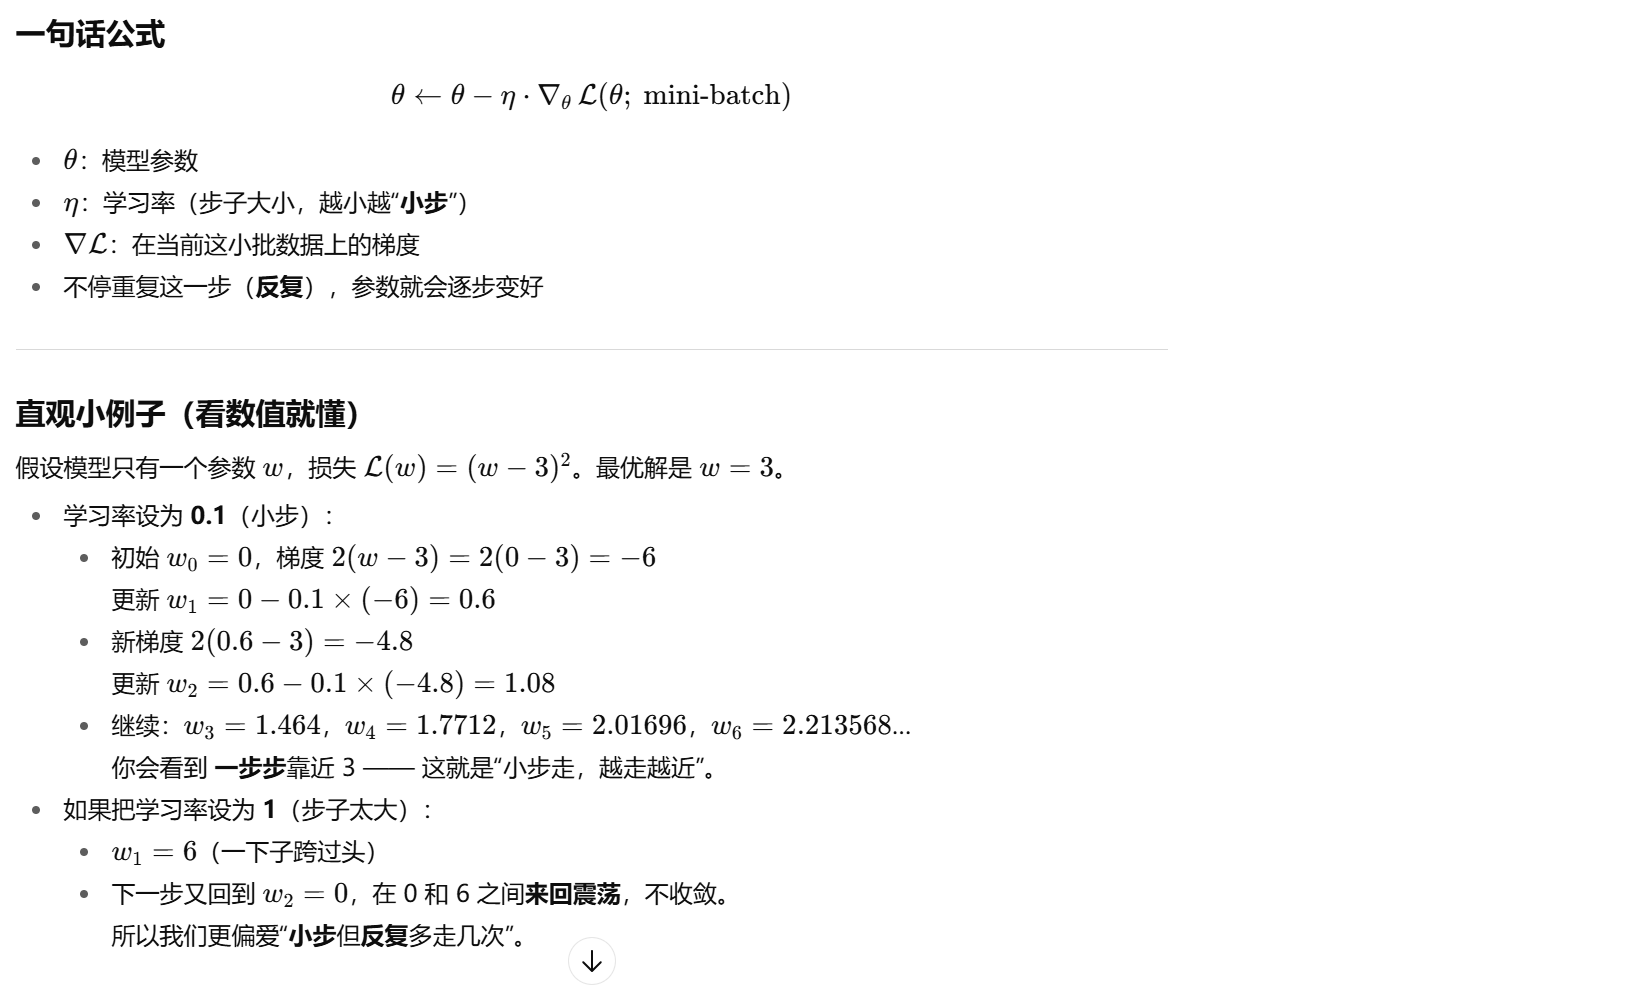

**多个epoch的效果：**

1 个 epoch = 把训练集完整走一遍。

step（更新步） = 用一小批数据（mini-batch）算梯度→更新一次参数。

每个 epoch 里有多少个 step？取决于 样本数 ÷ batch_size（再考虑梯度累积）。

所以 num_train_epochs=3 = 完整走 3 遍训练集 = 共进行 3×(steps_per_epoch) 次参数更新。

为了直观，我们假设每个 epoch 有 2 个 step（相当于训练集被分成 2 个小批次）。

| step |      w | L(w)=(w-3)^2    | 所在 epoch       |
| ---: | -------------------: | ------------------------------------: | ------------------------------ |
|    0 | 0.000000 |       9.000000 | epoch 1 开始     |
|    1 | 0.600000 |       5.760000 | epoch 1        |
|    2 | 1.080000 |       3.686400 | **epoch 1 结束** |
|    3 | 1.464000 |       2.359296 | epoch 2        |
|    4 | 1.771200 |       1.509949 | **epoch 2 结束** |
|    5 | 2.016960 |       0.966368 | epoch 3        |
|    6 | 2.213568 |       0.618475 | **epoch 3 结束** |


第 1 遍（epoch 1）：从 w=0 走两小步到 w=1.08，损失从 9 降到 3.6864。

第 2 遍（epoch 2）：再走两小步到w=1.7712。

第 3 遍（epoch 3）：再走两小步到 w=2.213568。

可见：随着 epoch 增加，参数在反复小步中不断靠近最优解 w=3，损失也持续下降

**为啥要用反复小步更新：**

算力/显存限制：一次用全数据算“精确梯度”太重，还装不下；mini-batch 更现实。

优化更好：小批量带来的“随机性”能帮助跳出差的局部最优，泛化通常更好。

稳定可控：步子小不易发散；配合学习率调度（warmup、线性/余弦衰减）更平滑。

**和训练参数怎么对应？**

per_device_train_batch_size：每次用一小批数据算梯度（“小步”的基础）。

num_train_epochs：把同一批训练数据反复走多遍（“反复”）。

learning_rate：真正的步子大小。

gradient_accumulation_steps：先走多个超小步再合成一次大更新，显存友好但仍保持“有效步子”

**总结：**

小步：学习率别太大，避免一脚跨过头。

反复：多次迭代/多轮 epoch，逐步逼近好解。

看验证集：指标见顶就停（或用 load_best_model_at_end + 早停）。

**为什么不只训练 1 遍？**

**需要更多迭代：**

训练 = 不停做梯度下降。一次“遍历数据”（1 epoch）能做的 更新步数有限，通常还没到“好解”。

例：你有 300 条样本，per_device_train_batch_size=4（单卡，无梯度累积）

每个 epoch 的步数 ≈ ceil(300/4)=75

只跑 1 个 epoch = 75 次更新，往往不够；跑 5 个 epoch = 375 次更新，更有机会收敛。

**每个 epoch 的“体验”都不同：**

打乱顺序（shuffle）：同样的数据，不同的批次顺序 → 不同的梯度噪声，可帮助跳出差的局部解，提升泛化。

随机正则：如 dropout、随机裁剪/遮挡等增强，让模型每轮都“见到不一样的版本”。

学习率调度：有 warmup、线性衰减/余弦衰减——后续 epoch 的学习率与第一轮不同，更新效果也不一样。

**统计学习角度**

小批量 SGD 的“噪声”有助于找到更平滑、泛化更好的解；通常需要多轮迭代逐步靠近。

**第二遍、第三遍与第一遍会有什么不同？**

参数已变：第一遍更新后，模型权重不再是初值；同样的数据再次前向/反向会产生不同的梯度。

批次/顺序不同：打乱后梯度顺序不同 → 收敛路径不同。

正则随机性：dropout/数据增强每次都不一样。

学习率变化：后续 epoch 往往学习率更小，更适合“细抛光”。
→ 这些都会让第 2、3… 遍继续带来额外的优化收益（直到收益递减甚至过拟合）。

# **日志信息**

可以看loss指标，梯度grad_norm,学习率learning_rate,轮次epoch。

日志可以帮助发现训练过程中有什么样的问题。比如说学习率过大，梯度爆炸这样的问题。

数据量比较大的情况下，日志太多会影响性能。

所以logging_steps要根据数据量来。

1) **一个 epoch 里有多少个“step”？**

设：

数据量 N

每设备批大小 B = per_device_train_batch_size

设备数 D（单卡=1，多卡/分布式训练>1）

梯度累积步数 A = gradient_accumulation_steps（默认 1）

则每优化器步消化的样本数 ≈ B * D * A，

每个 epoch 的优化器步数：

steps_per_epoch ≈ ceil( N / (B * D * A) )

总步数（跑 E 个 epoch）：

total_steps ≈ steps_per_epoch * E

2) 在单卡、无梯度累积且不丢最后一批的情况下，近似可以这么理解：

step = 总数据量 / per_device_train_batch_size * epochs 的轮数

要对每个 epoch 里 N / B 做向上取整（否则少算了最后那一小批）。

# **常用 TrainingArguments（精简到好用的）**

**训练循环与评估**

num_train_epochs: 训练轮数。小数据集建议 3–10，配合早停更稳。

per_device_train_batch_size: 单卡训练 batch。显存吃紧就小一点，再用梯度累积补回来。

per_device_eval_batch_size: 验证 batch。可稍大以加速评估。

gradient_accumulation_steps: 梯度累积步数。让有效 batch=train_bs * accum * 卡数。BERT 类任务常见有效 batch 16–64。

evaluation_strategy: 何时评估。"epoch"（每轮）或 "steps"（每 N 步）。

eval_steps: 当用 "steps" 时的评估间隔。

logging_strategy / logging_steps: 记录日志频率。步数太小会刷屏、太大看不出走势。

保存与最优模型

save_strategy: 何时保存，常用 "epoch"；或 "steps" 搭配 save_steps。

save_steps: 按步保存的间隔。

save_total_limit: 最多保留的 checkpoint 个数，防止磁盘爆。

load_best_model_at_end: 训练结束回滚到验证集上最优的 checkpoint（强烈推荐）。

metric_for_best_model: 用哪个指标选最优，如 "f1", "accuracy", "loss"。

greater_is_better: 指标是越大越好还是越小越好。

优化器与学习率

learning_rate: 学习率。BERT 类微调常在 2e-5～5e-5。

weight_decay: L2 正则，常用 0.01 抑制过拟合。

lr_scheduler_type: 学习率调度器，如 "linear", "cosine", "cosine_with_restarts"。

warmup_steps / warmup_ratio: 预热，建议 warmup_ratio=0.1 小数据更稳。

max_grad_norm: 梯度裁剪上限，默认 1.0 抑爆。

训练稳定性与精度

fp16 / bf16: 混合精度训练（GPU 支持就开），提速省显存。

seed: 随机种子，保证可复现。

label_smoothing_factor: 标签平滑，0–0.1 之间能降过拟合、对噪声标注更稳。

数据加载与性能

dataloader_num_workers: DataLoader 线程数，2–4 常够用。

dataloader_pin_memory: True 通常更快（GPU）。

optim: 优化器，默认 adamw，或试试 "adamw_torch_fused"（新显卡更快）。

日志/追踪

report_to: 关掉外部日志用 "none"；或 "tensorboard", "wandb" 等。

logging_first_step: 首步就打日志，便于看曲线起点。

**看指标调参：**

| 训练现象                           | 可能原因             | 调整建议（从上到下逐步尝试）                                                                                                                                                                                      |
| ------------------------------ | ---------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 训练 loss 降很快，验证 loss 提前上升，F1 变差 | 过拟合              | 减少 `num_train_epochs`；增大 `weight_decay` 到 `0.02`–`0.05`；降低 `learning_rate`（如 `2e-5 → 1e-5`）；`label_smoothing_factor=0.05`；开启 `load_best_model_at_end` + **加 `EarlyStoppingCallback(patience=1~2)`** |
| 训练/验证 loss 都高、F1 低             | 欠拟合或 LR 太小       | 适度增大 `learning_rate`（`2e-5 → 3e-5/5e-5`）或增加 `num_train_epochs`；增大**有效 batch**（提高 `gradient_accumulation_steps`）以稳定梯度                                                                                |
| 验证指标剧烈震荡                       | LR 偏大 / batch 偏小 | 降低 `learning_rate`；提高 `gradient_accumulation_steps`；用 `warmup_ratio=0.1`；改 `lr_scheduler_type="cosine"`（更平滑）                                                                                        |
| 训练很慢/显存不够                      | batch 太大         | 降 `per_device_train_batch_size`；开 `fp16`/`bf16`；增 `gradient_accumulation_steps` 保持有效 batch                                                                                                          |
| 准确率高但 F1 低（类不平衡）               | 指标不对齐            | 在 `compute_metrics` 里返回 `f1` 并设置 `metric_for_best_model="f1"`；（不在 TA 里）可给损失函数加类权重                                                                                                                   |


最常用：

| 指标/现象（验证集）                    | 调整参数                                                            | 动作与常见范围                                                              | 适用/注意                                                                                        |
| ----------------------------- | --------------------------------------------------------------- | -------------------------------------------------------------------- | -------------------------------------------------------------------------------------------- |
| loss 下降、F1 上不去（或震荡）           | `learning_rate`                                                 | 降低 LR（如 3e-5 → 2e-5 → 1e-5）                                          | 先调 LR 再看规律；用 `lr_scheduler_type="linear"` 更稳。([Hugging Face][1])                             |
| 验证 loss 提前上升、F1 回落（过拟合）       | `num_train_epochs`, `weight_decay`, `label_smoothing_factor`    | 减少轮次（如 6→4）、`weight_decay=0.01→0.02~0.05`、`label_smoothing=0.05`     | 同时开启 `load_best_model_at_end` + 早停。([Hugging Face][1])                                       |
| 指标抖动大（不稳定）                    | `gradient_accumulation_steps`, `warmup_ratio`                   | 提高有效 batch（如 16/32），`warmup_ratio≈0.1`                               | 震荡多半是 LR 偏大或 batch 偏小。([Hugging Face][1])                                                    |
| 训练慢/显存吃紧                      | `per_device_train_batch_size`, 混合精度                             | 降 batch、开 `fp16/bf16`                                                | `logging_steps` 不要太小以免 I/O 抢时间。([Hugging Face][1])                                           |
| Macro-F1 明显优于 Accuracy（类别不均衡） | 损失加权/采样、度量选择                                                    | 给稀有类加权；主要看 **Macro-F1 / MCC**；AUC 需结合 PR 曲线                          | AUPRC 并非总优于 AUROC（近年研究指出需具体情境判断）。([OpenReview][2], [arXiv][3], [科学直通车][4])                   |
| 提升早停与最优保存                     | `evaluation_strategy`, `save_strategy`, `metric_for_best_model` | 设 `"epoch"` 评估/保存，`load_best_model_at_end=True`，指标选 `"f1"`           | 与 `compute_metrics` 同步；W\&B/TB 记录曲线。([Hugging Face][1], [Weights & Biases Documentation][5]) |
| 学习率调度更平滑                      | `lr_scheduler_type`                                             | `linear` 或 `cosine`（可配 warmup）                                       | HF 支持直接设 `lr_scheduler_type`。([Hugging Face Forums][6])                                      |
| 阈值影响 Precision/Recall 取舍      | **决策阈值**                                                        | 在验证集上扫阈值，**最大化 F1 / Fβ / Youden** 后固定                                | 记得只在验证集上调阈值，再在测试集报告。([Hugging Face Forums][7], [arXiv][8], [Hugging Face][9])                |
| 指标可视化&追踪                      | `report_to`, `logging_steps`                                    | 接 W\&B：`report_to="wandb"`，合理设置 `logging_steps`                      | 便于对比不同超参的学习曲线。([Weights & Biases Documentation][5])                                          |
| 系统化 HPO（超参搜索）                 | `hyperparameter_search()`                                       | 用 Optuna/Ray Tune/ SigOpt 搜 `lr/weight_decay/epochs/warmup` 等；目标设 F1 | `Trainer` 原生支持多后端、多目标。([Hugging Face][10], [Ray Documentation][11])                          |

[1]: https://huggingface.co/docs/transformers/en/trainer?utm_source=chatgpt.com "Trainer"
[2]: https://openreview.net/forum?id=S3HvA808gk&utm_source=chatgpt.com "A Closer Look at AUROC and AUPRC under Class ..."
[3]: https://arxiv.org/html/2401.06091v1?utm_source=chatgpt.com "A Closer Look at AUROC and AUPRC under Class ..."
[4]: https://www.sciencedirect.com/science/article/pii/S2666389924001090?utm_source=chatgpt.com "The receiver operating characteristic curve accurately ..."
[5]: https://docs.wandb.ai/guides/integrations/huggingface/?utm_source=chatgpt.com "Hugging Face Transformers | Weights & Biases Documentation"
[6]: https://discuss.huggingface.co/t/using-cosine-lr-scheduler-via-trainingarguments-in-trainer/14783?utm_source=chatgpt.com "Using Cosine LR scheduler via TrainingArguments in Trainer"
[7]: https://discuss.huggingface.co/t/how-to-determine-the-best-threshold-for-predictions-when-making-inference-with-a-finetune-model/13001?utm_source=chatgpt.com "HOW TO determine the best threshold for predictions when making ..."
[8]: https://arxiv.org/abs/1402.1892?utm_source=chatgpt.com "[1402.1892] Thresholding Classifiers to Maximize F1 Score - arXiv"
[9]: https://huggingface.co/spaces/evaluate-metric/f1?utm_source=chatgpt.com "F1 - a Hugging Face Space by evaluate-metric"
[10]: https://huggingface.co/docs/transformers/en/hpo_train?utm_source=chatgpt.com "Hyperparameter search"
[11]: https://docs.ray.io/en/latest/tune/index.html?utm_source=chatgpt.com "Ray Tune: Hyperparameter Tuning — Ray 2.49.0 - Ray Docs"


最新 & 近两年受欢迎的做法（结合小样本/Transformer微调）：

| 做法                                     | 观察的指标/收益                | 如何落地（与 TA/Trainer 结合）                                       | 注意/证据                                                        |
| -------------------------------------- | ----------------------- | ----------------------------------------------------------- | ------------------------------------------------------------ |
| **Optuna / Ray Tune + ASHA/PBT** 自动化搜索 | 验证 **Macro-F1**/loss 提升 | `trainer.hyperparameter_search()` 指定后端与搜索空间；Ray 支持 PBT/ASHA | 官方文档与 Ray 最新版均推荐。([Hugging Face][1], [Ray Documentation][2]) |
| **层级学习率衰减（LLRD）**                      | 验证 F1 提升、过拟合降低          | 高层较大学习率、底层较小；可分组参数传给优化器                                     | 在视觉/语言微调里被反复验证有效。([arXiv][3], [Medium][4])                   |
| **Cosine（含重启）/One-Cycle** 调度           | 曲线更平滑、收敛快               | `lr_scheduler_type="cosine"`，或自定义 One-Cycle                 | Cosine 在 HF/社区中应用广泛。([Hugging Face Forums][5])               |
| **EMA（指数滑动平均权重）**                      | 验证 F1/稳定性提升             | 训练时维护 EMA 权重，评估/导出用 EMA                                     | 2024 系统性研究支持其泛化收益。([arXiv][6])                               |
| **温度缩放（校准）**                           | ECE/BS 分数下降，阈值更稳        | 训练后在验证集拟合温度；推理前先做温度缩放再阈值                                    | 经典且在深网中有效。([users.cs.fiu.edu][7], [eng.biu.ac.il][8])        |
| **基于 PR-Curve 的阈值优化**                  | Macro-F1 / AUPRC 提升     | 在验证集扫阈值，以目标指标最优为准                                           | 阈值与指标强相关，需单独调优。([Hugging Face Forums][9])                    |
| **（有条件）SAM/LookSAM/R-Drop 等正则**        | 期望更好泛化                  | 替换/包裹优化器或增加一致性正则                                            | **NLP 场景对 SAM 的收益存在分歧**，近期研究提示需谨慎。([arXiv][10], [ICML][11])  |
| **部分冻结 + 渐进解冻**                        | 小数据更稳，F1 更平滑            | 先冻结底层，观察指标后逐层解冻；结合 LLRD                                     | CLIP/Transformer 微调实证常见。([arXiv][3])                         |
| **多目标 HPO（F1+AUROC/Latency）**          | 兼顾效果与效率                 | `hyperparameter_search` 支持多目标；Ray/W\&B 做权衡面                 | 适合生产落地。([Hugging Face][1])                                   |
| **度量选择的最新共识**                          | 指标更贴合任务                 | **不要机械地“类不均衡就只看 AUPRC”**；结合 AUROC/PR-Curve与业务代价             | 2024–2025 多篇论文讨论了误区与条件。([arXiv][12], [科学直通车][13])            |

[1]: https://huggingface.co/docs/transformers/en/hpo_train?utm_source=chatgpt.com "Hyperparameter search"
[2]: https://docs.ray.io/en/latest/tune/index.html?utm_source=chatgpt.com "Ray Tune: Hyperparameter Tuning — Ray 2.49.0 - Ray Docs"
[3]: https://arxiv.org/pdf/2212.06138?utm_source=chatgpt.com "arXiv:2212.06138v1 [cs.CV] 12 Dec 2022"
[4]: https://medium.com/%40hassaanidrees7/fine-tuning-transformers-techniques-for-improving-model-performance-4b4353e8ba93?utm_source=chatgpt.com "Fine-Tuning Transformers: Techniques for Improving ..."
[5]: https://discuss.huggingface.co/t/using-cosine-lr-scheduler-via-trainingarguments-in-trainer/14783?utm_source=chatgpt.com "Using Cosine LR scheduler via TrainingArguments in Trainer"
[6]: https://arxiv.org/html/2411.18704v1?utm_source=chatgpt.com "Exponential Moving Average of Weights in Deep Learning"
[7]: https://users.cs.fiu.edu/~sjha/class2023/Lecture8/Slides/2017TemperatureScaling.pdf?utm_source=chatgpt.com "On Calibration of Modern Neural Networks: Temperature ..."
[8]: https://www.eng.biu.ac.il/goldbej/files/2023/05/calibration_tutorial.pdf?utm_source=chatgpt.com "Neural Network Calibration Jacob Goldberger"
[9]: https://discuss.huggingface.co/t/how-to-determine-the-best-threshold-for-predictions-when-making-inference-with-a-finetune-model/13001?utm_source=chatgpt.com "HOW TO determine the best threshold for predictions when making ..."
[10]: https://arxiv.org/html/2502.02407v1?utm_source=chatgpt.com "Avoiding spurious sharpness minimization broadens ..."
[11]: https://icml.cc/virtual/2025/poster/43667?utm_source=chatgpt.com "Avoiding spurious sharpness minimization broadens ..."
[12]: https://arxiv.org/html/2401.06091v1?utm_source=chatgpt.com "A Closer Look at AUROC and AUPRC under Class ..."
[13]: https://www.sciencedirect.com/science/article/pii/S2666389924001090?utm_source=chatgpt.com "The receiver operating characteristic curve accurately ..."


# **训练器Trainer**

In [19]:
#训练器，这是huggingface提供的高级训练封装器

trainer = Trainer(
    model = model,#传入模型
    args = training_args,#传入训练配置
    train_dataset = encoding_dataset,#传入数据
)

#自动会处理很多的细节，能够帮助我们启动调试模型训练的过程

In [20]:
#开始训练，会自动打印出损失和进度，可以看到每个训练轮次的进展

trainer.train()

Step,Training Loss
5,0.787500
10,0.621200
15,0.387700
20,0.167200
25,0.796700
30,0.466400
35,0.428600
40,0.314800
45,0.476300
50,0.519300


TrainOutput(global_step=375, training_loss=0.13629121835716068, metrics={'train_runtime': 644.9427, 'train_samples_per_second': 4.644, 'train_steps_per_second': 0.581, 'total_flos': 197004402700800.0, 'train_loss': 0.13629121835716068, 'epoch': 5.0})

In [21]:
#保存模型

trainer.save_model("output/zh_model")

In [22]:
#将分词器也保存下来，后续部署或者推理时用。
tokenizer.save_pretrained("output/zh_model")

#可以在工具夹那里output-tokenizer.json
#在这个文件中可以进行查找。比如输入"我"，能看到它对应的一串数字，这个tokenizer是和我的数据配套

('output/zh_model/tokenizer_config.json',
 'output/zh_model/special_tokens_map.json',
 'output/zh_model/vocab.txt',
 'output/zh_model/added_tokens.json',
 'output/zh_model/tokenizer.json')

原始文件中有的只是配置文件：tokenizer.config.json，而真正能查找的分词器是模型训练时保存下来的，即tokenizer.json。

# **training loss**

**1) 为什么 training loss 不是一直下降？**

完全正常。原因主要有：

打印的是“**最近一段窗口的平均损失**”：logging_steps=5 时，HF Trainer 在每次打日志时，会把最近 5 个小批次的 loss 做平均后打印，而**不是**到目前为止的**全局均值**、更不是“最佳值”。这种滑动窗口均值本来就会上下抖动。

每个 epoch 都会**打乱**（shuffle）数据：新 epoch 的前几个 batch 可能正好更“难”，于是你会看到在 75, 150, 225, 300（这些是 epoch 边界附近）后面的一小段，loss 常常短暂抬头（你的日志里 90110、185210 就是第二、第三个 epoch 早期的波动）。

小数据 + 小 batch 的噪声：599 条、batch_size=8 ⇒ **一个日志窗口仅 5×8=40 条样本，随机性很大**；再加上 dropout 等正则，mini-batch 平均损失天然会起伏。

小结：期望上会下降，但曲线不必单调，看局部抖动是正常的。

**2) 这代表需要减 epoch 或改参吗（会不会过拟合）？**

单看训练损失**无法**判断过拟合。你有很多 step 的训练损失已经接近 0.000x，这说明模型对训练集学得很“顺”，是否过拟合要看验证集：

如果**验证集指标**（比如 F1/准确率）很早就不再提升，甚至开始下降，而训练损失继续接近 0，那就是过拟合信号 ⇒ 应该早点停或加强正则。

如果验证集还在稳步变好，那就不用担心训练曲线的小波动。

**3) 如果验证集显示过拟合，怎么调？**

优先级从上到下：

更早停：num_train_epochs=2~3，EarlyStoppingCallback(patience=1)。

学习率再小一点：2e-5（很多中文 RoBERTa 微调用 2e-5 ~ 5e-5，小数据更倾向小一点）。

正则化：weight_decay=0.01（你已加），可再加 label_smoothing_factor=0.05（在 TrainingArguments 里支持），缓解过度自信。

warmup：warmup_ratio=0.1 有助于训练前期更平稳。

冻结底层（可选）：先冻结 6~9 层 encoder，减少可训练参数，降低过拟合风险。

类不平衡（如存在）：给损失加权（自定义 compute_loss 或在 Trainer 里传入 class weights）。

**早停Early Stopping是什么？**

训练时一直监控验证集（dev/val set）的指标（如 eval_loss、accuracy、F1）。
如果连续好几轮（几个 epoch）都没有更好了，就提前把训练停掉，并保留效果最好的那次模型。

**为什么要用早停？**

防过拟合：模型在训练集越学越好，但验证集不再提升甚至变差——早点停更好。

省时间/显存：不再浪费后面“基本没收益”的训练。

**怎么判断早停时机？**

有两个小参数很关键：

patience（耐心）：允许“暂时不进步”的最多 epoch 数。例如 patience=2：连续 2 个 epoch 没提升，就停。

min_delta / threshold（最小提升幅度）：提升要超过这个阈值才算“进步”。比如 1e-4。

例子：监控指标是 验证集 F1（越大越好），patience=2，threshold=1e-4：

| Epoch |         Val F1         |
| ----: | :--------------------: |
|     1 |          0.71          |
|     2 |          0.77          |
|     3 |       0.78 ← 当前最好      |
|     4 | 0.7800（增量 < 1e-4，不算提升） |
|     5 |          0.779         |
|     6 |          0.777         |


从第 3 个 epoch 之后连续 2 个 epoch（第 4、5）都没实质提升，因此在开始第 6 个 epoch 之前停止训练，并把第 3 个 epoch 的最好模型拿回来。

In [23]:
"""
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback

training_args = TrainingArguments(
    output_dir="output/zh_model",
    per_device_train_batch_size=8,
    num_train_epochs=10,                 # 可以给大一点，交给早停控制何时停
    evaluation_strategy="epoch",         # 要有验证评估，早停才能判断
    save_strategy="epoch",
    load_best_model_at_end=True,         # 训练结束自动加载“最好”的那次
    metric_for_best_model="f1",          # 你想监控的指标名
    greater_is_better=True,              # F1/Acc 是越大越好；loss 则是 False
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=valid_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,     # 返回 dict，比如 {"f1": ..., "accuracy": ...}
    callbacks=[EarlyStoppingCallback(
        early_stopping_patience=2,       # 连续 2 个 epoch 无提升就停
        early_stopping_threshold=1e-4    # 至少提升这么多才算进步
    )]
)

trainer.train()
"""

'\nfrom transformers import TrainingArguments, Trainer, EarlyStoppingCallback\n\ntraining_args = TrainingArguments(\n    output_dir="output/zh_model",\n    per_device_train_batch_size=8,\n    num_train_epochs=10,                 # 可以给大一点，交给早停控制何时停\n    evaluation_strategy="epoch",         # 要有验证评估，早停才能判断\n    save_strategy="epoch",\n    load_best_model_at_end=True,         # 训练结束自动加载“最好”的那次\n    metric_for_best_model="f1",          # 你想监控的指标名\n    greater_is_better=True,              # F1/Acc 是越大越好；loss 则是 False\n)\n\ntrainer = Trainer(\n    model=model,\n    args=training_args,\n    train_dataset=train_ds,\n    eval_dataset=valid_ds,\n    tokenizer=tokenizer,\n    compute_metrics=compute_metrics,     # 返回 dict，比如 {"f1": ..., "accuracy": ...}\n    callbacks=[EarlyStoppingCallback(\n        early_stopping_patience=2,       # 连续 2 个 epoch 无提升就停\n        early_stopping_threshold=1e-4    # 至少提升这么多才算进步\n    )]\n)\n\ntrainer.train()\n'

使用小贴士

必须有验证集（eval_dataset）并定期评估（evaluation_strategy="epoch" 或 "steps"），否则早停无从判断。

指标方向要对：监控 loss 时设 greater_is_better=False；监控 F1/Acc 设 True。

patience 设太小可能过早停止；太大又起不到省时作用。小数据集常用 1~2。

有噪声时加 early_stopping_threshold，避免指标小数点后微抖就触发“提升”。

早停 = 持续观察验证集 → 连续若干轮没实质提升就刹车 → 自动保留最优检查点。

**怎么把学习率调小（HF Trainer）？**

最直接：在 TrainingArguments 里设更小的 learning_rate，顺便配个热身与衰减更稳

In [24]:
"""
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="output/zh_model",
    per_device_train_batch_size=8,
    num_train_epochs=3,              # 小数据先给 2~3，交给早停控制
    learning_rate=2e-5,             # 常见微调：5e-5 → 3e-5 → 2e-5 → 1e-5
    lr_scheduler_type="linear",     # 线性衰减（默认也是 linear）
    warmup_ratio=0.1,               # 前 10% 步数热身
    weight_decay=0.01,              # L2 正则
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_steps=5,
    seed=42,
)
"""

'\nfrom transformers import TrainingArguments\n\ntraining_args = TrainingArguments(\n    output_dir="output/zh_model",\n    per_device_train_batch_size=8,\n    num_train_epochs=3,              # 小数据先给 2~3，交给早停控制\n    learning_rate=2e-5,             # 常见微调：5e-5 → 3e-5 → 2e-5 → 1e-5\n    lr_scheduler_type="linear",     # 线性衰减（默认也是 linear）\n    warmup_ratio=0.1,               # 前 10% 步数热身\n    weight_decay=0.01,              # L2 正则\n    evaluation_strategy="epoch",\n    save_strategy="epoch",\n    load_best_model_at_end=True,\n    metric_for_best_model="f1",\n    greater_is_better=True,\n    logging_steps=5,\n    seed=42,\n)\n'

**为什么把学习率（LR）调小能缓解过拟合？**

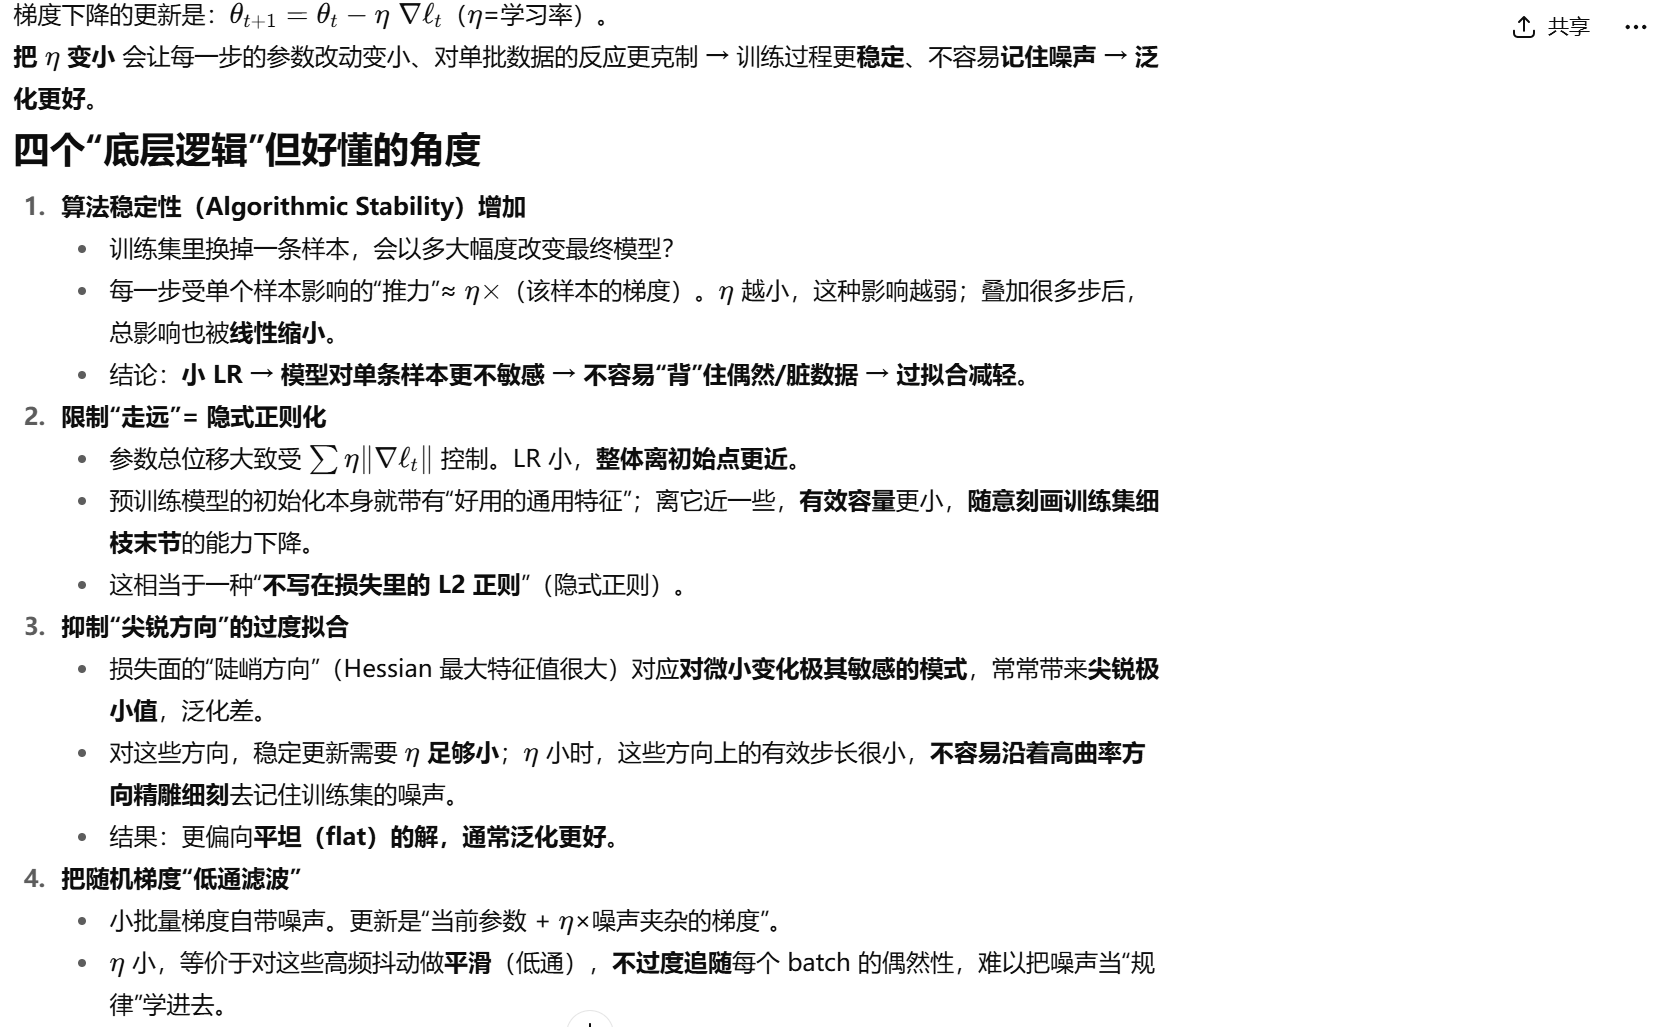

针对该任务的简单实操建议：

从 3e-5 或 2e-5 开始试（之前默认 5e-5）。

保持 warmup_ratio=0.1，weight_decay=0.01，加 早停（patience=1~2）。

观察验证集：

若**把 LR 降一档**后，训练集指标差不多、验证集更好 → 之前 LR 偏大、过拟合在缓解；

若**训练与验证都都**差 → LR 可能太小（或训练不充分），可略增或多 1 个 epoch。

额外提示（可选）

Label smoothing（label_smoothing_factor=0.05）能显著抑制“过度自信”。

冻结底层几层 encoder（或用 LoRA）减少可训练参数，也能降过拟合。

减小 batch会增大 SGD 噪声，也常带来更好泛化（但速度慢一些）。

**正则化是啥？**

给模型“束手束脚”，不要让它把训练集细节（包括噪声、偶然性、错标）都背下来，从而在新数据上更稳。

做法上，要么在损失里加惩罚，要么在结构/训练过程中制造约束或随机性。

最常用的 4 种正则化：

1) L2 正则 / 权重衰减（weight decay）

直觉：不让参数长得太“肥”。系数越大，惩罚越大；逼着模型用更小、更温和的参数表达规律，减少“刻”训练集细节的能力。

在 HF 里：TrainingArguments(weight_decay=0.01)（常用 0.01）。

2) Dropout（随机丢弃）

直觉：训练时随机关掉一部分神经元，让模型学会在“缺胳膊少腿”时也能工作，减少“依赖某个特征组合”的过拟合。

在 HF 里：用带更高 dropout 的 config 初始化模型（改完需要用这个 config 重新 from_pretrained）。

In [25]:
"""
from transformers import AutoConfig, AutoModelForSequenceClassification
config = AutoConfig.from_pretrained(
    model_name,
    hidden_dropout_prob=0.2,          # 常见 0.1~0.2
    attention_probs_dropout_prob=0.2
)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, config=config, num_labels=2
)
"""

'\nfrom transformers import AutoConfig, AutoModelForSequenceClassification\nconfig = AutoConfig.from_pretrained(\n    model_name,\n    hidden_dropout_prob=0.2,          # 常见 0.1~0.2\n    attention_probs_dropout_prob=0.2\n)\nmodel = AutoModelForSequenceClassification.from_pretrained(\n    model_name, config=config, num_labels=2\n)\n'

3) Label Smoothing（标签平滑）

直觉：把**“正确类=100%”改成“正确类=95%，其余类平分 5%”。
这样模型别太自信**，不去把训练样本“打满分”→ 泛化更好。

在 HF 里：label_smoothing_factor=0.05（二分类/小数据很常用）。

4) 约束容量：冻结底层 / 少训一点参数

直觉：先把底层特征当“通用特征”直接用，只训练上面的几层/分类头；可训练参数少了，模型表达力被限制，更不容易过拟合。

在 HF（以中文 RoBERTa/BERT 结构为例，先冻前 6 层）：

In [26]:
"""
# 冻结 embedding + 前6层 encoder
for p in model.bert.embeddings.parameters():
    p.requires_grad = False
for layer in model.bert.encoder.layer[:6]:
    for p in layer.parameters():
        p.requires_grad = False
"""

'\n# 冻结 embedding + 前6层 encoder\nfor p in model.bert.embeddings.parameters():\n    p.requires_grad = False\nfor layer in model.bert.encoder.layer[:6]:\n    for p in layer.parameters():\n        p.requires_grad = False\n'

**如何判断“正则化生效了”？**

训练集：loss/acc 可能略差一点（因为被“束缚”了）。

验证集：F1/准确率上升或更稳定；**训练-验证差距缩小**。

若训练、验证都差 → 正则太强（或学习率太小），就稍微放松（减小 weight_decay/dropout，或解冻多一两层）。

总之，正则化的目的不是让训练集更低，而是让“看不见的新数据”更好。
把上面的 4 招当“旋钮”，按你的验证集指标慢慢拧，基本就能把过拟合压住。

# **模型验证**

效果怎么样，怎么做评测一定要根据我们的训练参数来。

在训练日志中可以看到：

loss越低，效果越好，但是它不是绝对的，要看它在业务上的一个作用。

loss：模型的预测和实际标签的差距。

grad_norm：反应训练中间梯度的大小，梯度大说明有较大的更新步骤，到训练后期会慢慢缩小，代表训练过程趋于稳定。

learning_rate：学习率也在训练过程中不断衰减，有助于在训练期间，稳定模型，避免震荡。

以下指标表明训练效率。除了这些指标外还取决于数据大小和硬件资源。

train_runtime：整体训练时间 秒。

train_samples_per_second：每秒处理了多少个样本。

train_steps_per_second：每秒钟完成 步。

train_loss：最后的结果的损失。

epoch：轮次。

In [27]:
import torch
from sklearn.metrics import accuracy_score,f1_score,classification_report

In [31]:
#指定训练好的模型保存的路径
model_path="output/zh_model"

In [32]:
#加载模型和分词器

model = AutoModelForSequenceClassification.from_pretrained(model_path)
#从指定路径加载预训练模型
tokenizer = AutoTokenizer.from_pretrained(model_path)
#从指定路径加载与模型匹配的分词器

In [33]:
#设置模型为评估模式
#说明模型现在不是学习的状态
model.eval()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(21128, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

**.eval() 是什么？**

它把模型切到评估模式（model.training = False），并递归作用到所有子模块。

影响前向传播时某些层的行为，最主要是：

Dropout：关闭（不再随机丢弃神经元）。

BatchNorm：不再用当前 batch 的均值/方差，改用运行时累计的均值/方差，同时也不再更新这些统计量。

对于大多数 Transformer/LLM（普遍用 LayerNorm 而不是 BatchNorm），最实际的影响就是关闭 Dropout。

**用完有什么变化？**

权重没变。只是模型内部“评估开关”被置为 False（Dropout 关、BatchNorm 用累计统计）。

想继续训练，需要切回训练模式：model.train()。

In [34]:
#测试集数据，包含文本和对应的真实标签
#测试集数据也要平衡
test_data=[
  {"text":"房间有些陈旧！不过还算舒适，交通也方便。","label":1},
  {"text":"早餐30,不能退,也不能延期，以后不再住这个酒店.房间有味。","label":0},
  {"text":"酒店位置不错,在市中心,服务态度很好,设施还可以.只是床太硬。","label":1},
  {"text":"服务还可以！别的和招待所水平差不多。网络经常不好！总体不值得推荐！","label":0},
  {"text":"地理位置很方便，楼下就有地铁站！对面就是来福士，楼下周边有很多美食店铺，酒店旁边还有服装皮箱批发城。","label":1},
  {"text":"房间宣传图片和实际出入较大哈，住这里的旅客要考虑考虑。","label":0},
  {"text":"整体给人放松舒适的感觉，色彩也不黯淡。早餐非常可口！ 员工友好、亲切而尽心尽力。地理位置也好，闹中取静。","label":1},
  {"text":"网连不上，叫人也没有人来修","label":0},
  {"text":"酒店是现代风格，房间很宽敞也很漂亮，泳池很棒，早餐种类和用料都很丰富，负责任而友好的员工。","label":1},
  {"text":"有陌生人突然进我们房间。","label":0},
]

In [35]:
#定义类别映射
label_map = {0:"负面",1:"正面"}

In [36]:
#准备测试数据
texts = [item["text"] for item in test_data]
true_labels = [item["label"] for item in test_data]

test_data 是由**字典组成的列表**。每个元素（叫 **item**）都是一条样本，里面有两个键："text" 和 "label"。

item["text"] 的意思是：从这一条样本的字典里，取出键为 "text" 的值（也就是评论文本）；同理，item["label"] 取出标签。

texts = [
  "房间有些陈旧！不过还算舒适，交通也方便。",

  "早餐30,不能退,也不能延期，以后不再住这个酒店.房间有味。",

  "酒店位置不错,在市中心,服务态度很好,设施还可以.只是床太硬。",

  "服务还可以！别的和招待所水平差不多。网络经常不好！总体不值得推荐！",

  "地理位置很方便，楼下就有地铁站！对面就是来福士，楼下周边有很多美食店铺，酒店旁边还有服装皮箱批发城。",

  "房间宣传图片和实际出入较大哈，住这里的旅客要考虑考虑。",

  "整体给人放松舒适的感觉，色彩也不黯淡。早餐非常可口！ 员工友好、亲切而尽心尽力。地理位置也好，闹中取静。",

  "网连不上，叫人也没有人来修",

  "酒店是现代风格，房间很宽敞也很漂亮，泳池很棒，早餐种类和用料都很丰富，负责任而友好的员工。",
  
  "有陌生人突然进我们房间。"
]

true_labels = [1, 0, 1, 0, 1, 0, 1, 0, 1, 0]


In [37]:
#对测试及数据进行分词，编码，指定max_length来避免警告
inputs = tokenizer(texts, padding=True, truncation = True, return_tensors="pt", max_length = 128)

return_tensors="pt" 的意思是：把分词后的结果直接转换成 PyTorch 的张量（tensor） 返回。
"pt" 就是 PyTorch 的缩写。这样你就能把这些张量直接喂给用 PyTorch 写的模型（如 AutoModelForSequenceClassification）。

不写时：默认返回 Python 的列表（list），你还得自己再转成 tensor。

其他可选值：

"np" → 返回 NumPy 数组

"tf" → 返回 TensorFlow 张量

In [38]:
#使用模型进行推理
predictions = []
with torch.no_grad():
  #进入“无梯度”环境：只前向计算，不记录梯度
  outputs = model(**inputs)
  #前向：把inputs字典展开传给模型，相当于model(input_ids=..., attention_mask=..., ...)
  logits = outputs.logits
  #取出“logits”：每个样本对每个类别的原始分数（未softmax）
  predicted_classes = torch.argmax(logits,dim=1).tolist()#获取预测结果，沿类别维度取最大值的位置（类别ID）
  predictions = predicted_classes


这段代码在**推理阶段（inference）**做了三件事：

关掉梯度计算来省显存/提速；2) 用模型算出logits（未归一化分数）；3) 取每个样本分数里最大的那个类别索引当作预测结果（argmax）。



In [39]:
#计算评估指标
acc = accuracy_score(true_labels, predictions)
print(f"准确率：{acc:.4f}")

准确率：1.0000


In [40]:
#计算F1分数

f1 = f1_score(true_labels, predictions)
print(f"F1分数：{f1:.4f}")

F1分数：1.0000


In [41]:
#分类报告
print("分类报告：")
print(classification_report(true_labels, predictions, target_names = ["正面 ","负面 "]))

分类报告：
              precision    recall  f1-score   support

         正面        1.00      1.00      1.00         5
         负面        1.00      1.00      1.00         5

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



In [42]:
#打印模型预测结果
for text, true_label, predicted_class in zip(texts, true_labels, predictions):
  print(f"测试文本: {text}")
  print(f"真实标签: {label_map[true_label]}")
  print(f"预测标签: {label_map[predicted_class]}")

测试文本: 房间有些陈旧！不过还算舒适，交通也方便。
真实标签: 正面
预测标签: 正面
测试文本: 早餐30,不能退,也不能延期，以后不再住这个酒店.房间有味。
真实标签: 负面
预测标签: 负面
测试文本: 酒店位置不错,在市中心,服务态度很好,设施还可以.只是床太硬。
真实标签: 正面
预测标签: 正面
测试文本: 服务还可以！别的和招待所水平差不多。网络经常不好！总体不值得推荐！
真实标签: 负面
预测标签: 负面
测试文本: 地理位置很方便，楼下就有地铁站！对面就是来福士，楼下周边有很多美食店铺，酒店旁边还有服装皮箱批发城。
真实标签: 正面
预测标签: 正面
测试文本: 房间宣传图片和实际出入较大哈，住这里的旅客要考虑考虑。
真实标签: 负面
预测标签: 负面
测试文本: 整体给人放松舒适的感觉，色彩也不黯淡。早餐非常可口！ 员工友好、亲切而尽心尽力。地理位置也好，闹中取静。
真实标签: 正面
预测标签: 正面
测试文本: 网连不上，叫人也没有人来修
真实标签: 负面
预测标签: 负面
测试文本: 酒店是现代风格，房间很宽敞也很漂亮，泳池很棒，早餐种类和用料都很丰富，负责任而友好的员工。
真实标签: 正面
预测标签: 正面
测试文本: 有陌生人突然进我们房间。
真实标签: 负面
预测标签: 负面


在面临大量数据时，准确率和F1分数可能不为1，因为1是满分，代表我训练的模型效果特别好。

在测试集小的时候，这些指标并不能充分反映模型的真实能力（可能是过拟合了小数据集的特征）。

用大的数据集训练和评估模型可以避免过拟合，评估结果更加可靠。

测试集的样本太少会影响评估结果的稳定性和代表性。

测试集应该够大，能够反映全部情况，才能准确地评估模型的泛化能力。

也可以通过交叉验证，来进行训练和测试，来确保模型的泛化能力和稳定性。

结合多个评估指标，做全面的分析

微调时喂给模型的数据需要和实际场景一模一样，标注也要准确。